# 第5章 単層ネットワーク: 分類 (Single-layer Networks: Classification)
## 章末演習問題 (Exercises 5.1 〜 5.24)

---

### 本ノートブックの構成と目的
本ノートブックは、Christopher M. Bishop & Hugh Bishop (2024) *『Deep Learning: Foundations and Concepts』* Springer 第5章末に収録された**全24問の演習問題 (Exercises 5.1 〜 5.24)** の完全な理論証明、数式厳密展開、穴埋め・自己評価問題、および Python による数値検証コード集です。

各問題は以下の構成で完全に記述されています：
1. **問題文（英語原文および日本語訳）**
2. **証明・導出の厳密な道筋（LaTeX による完全なステップ展開）**
3. **理解度確認（穴埋め形式・選択形式のチェック問題とその解答解説）**
4. **Python による数値的検証コードと自己採点アサーション (`assert`)**

---

### 演習問題一覧
- **Exercise 5.1 (?)**: 1-of-K 符号化における条件付き期待値 $\mathbb{E}[\mathbf{t}|\mathbf{x}] = p(C_k|\mathbf{x})$ の証明
- **Exercise 5.2 (? ?)**: 凸包 (Convex Hull) の共通部分と線形分離可能性の同値性の幾何学的証明
- **Exercise 5.3 (? ?)**: 最小二乗法による分類モデルにおける線形制約条件の保存定理（$\mathbf{a}^T \mathbf{y}(\mathbf{x}) + b = 0$）
- **Exercise 5.4 (? ?)**: 複数の線形制約条件が同時に満たされる場合の最小二乗予測の制約保存への拡張
- **Exercise 5.5 (?)**: 適合率 $P$ と再現率 $R$ の調和平均から $F_\beta$ スコア公式の厳密導出
- **Exercise 5.6 (? ?)**: 不等式 $a \le \sqrt{ab}$ を用いた最小誤分類確率のバッタチャリア上界の証明
- **Exercise 5.7 (?)**: 0-1 損失行列 $L_{kj} = 1 - I_{kj}$ における期待損失最小化と最大事後確率基準の等価性
- **Exercise 5.8 (?)**: 一般の損失行列と一般の事前確率における期待損失最小化決定基準の導出
- **Exercise 5.9 (?)**: 事後確率の標本平均の大数の法則によるクラス事前確率 $p(C_k)$ への収束証明
- **Exercise 5.10 (? ?)**: 棄却オプション損失 $\lambda$ と最適決定基準、棄却閾値 $\theta = 1 - \lambda$ の関係導出
- **Exercise 5.11 (?)**: ロジスティック・シグモイド関数の点対称性 $\sigma(-a) = 1 - \sigma(a)$ とロジット関数の導出
- **Exercise 5.12 (?)**: 2クラス・ガウス生成モデル（共有共分散）における線形パラメータ $\mathbf{w}, w_0$ の導出
- **Exercise 5.13 (?)**: $K$ クラス生成モデルにおけるクラス事前確率 $\pi_k = N_k / N$ のラグランジュ未定乗数法による最尤推定
- **Exercise 5.14 (? ?)**: 共有共分散行列を持つガウス生成分類器のクラス平均 $\boldsymbol{\mu}_k$ および共分散 $\boldsymbol{\Sigma}$ の最尤推定
- **Exercise 5.15 (? ?)**: 離散2値特徴量を持つナイーブベイズ分類器のパラメータ最尤推定
- **Exercise 5.16 (? ?)**: 多状態離散特徴量 (1-of-L) を持つナイーブベイズ事後確率の対数線形性の証明
- **Exercise 5.17 (? ?)**: 多状態離散ナイーブベイズモデルのカテゴリ頻度最尤推定
- **Exercise 5.18 (?)**: シグモイド関数の導関数公式 $\frac{d\sigma}{da} = \sigma(1 - \sigma)$ の微分証明
- **Exercise 5.19 (?)**: ロジスティック回帰の交差エントロピー誤差勾配 $\sum_n (y_n - t_n)\boldsymbol{\phi}_n$ の導出
- **Exercise 5.20 (?)**: 線形分離可能データにおける最尤推定の重み発散（$\|\mathbf{w}\| \to \infty$）の証明
- **Exercise 5.21 (?)**: ソフトマックス活性化関数のヤコビ行列 $\frac{\partial y_k}{\partial a_j} = y_k(I_{kj} - y_j)$ の導出
- **Exercise 5.22 (?)**: 多クラス交差エントロピー誤差の勾配 $\sum_n (y_{nj} - t_{nj})\boldsymbol{\phi}_n$ の導出
- **Exercise 5.23 (?)**: プロビット関数 $\Phi(a)$ と誤差関数 $\text{erf}(a)$ の解析的関係の証明
- **Exercise 5.24 (? ?)**: プロビット関数によるシグモイド関数のスケール近似（原点傾き一致条件 $\lambda^2 = \pi/8$）の証明


In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate, special
from scipy.optimize import linprog
from scipy.stats import norm

# プロジェクトルートの追加
repo_root = os.path.abspath('..')
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from common.plot_utils import setup_style
from common.discriminative_classifiers import sigmoid, probit
from common.exercises_ch5 import (
    exercise_5_1_conditional_expectation,
    exercise_5_2_check_separability,
    exercise_5_3_verify_linear_constraint,
    exercise_5_4_verify_multiple_constraints,
    exercise_5_5_compute_f_score,
    exercise_5_6_compute_bhattacharyya_bound,
    exercise_5_7_zero_one_loss_decision,
    exercise_5_8_expected_loss_decision,
    exercise_5_9_average_posterior,
    exercise_5_10_reject_threshold,
    exercise_5_11_verify_sigmoid_properties,
    exercise_5_12_compute_gaussian_gda_params,
    exercise_5_13_mle_priors,
    exercise_5_14_mle_gaussian_shared_cov,
    exercise_5_15_mle_binary_naive_bayes,
    exercise_5_16_multistate_naive_bayes_ak,
    exercise_5_17_mle_multistate_naive_bayes,
    exercise_5_18_verify_sigmoid_derivative,
    exercise_5_19_verify_logistic_gradient,
    exercise_5_20_separable_growth_check,
    exercise_5_21_verify_softmax_jacobian,
    exercise_5_22_verify_softmax_gradient,
    exercise_5_23_verify_probit_erf,
    exercise_5_24_probit_sigmoid_matching_scale,
)

setup_style()
print("第5章 演習問題セットアップ完了！")


第5章 演習問題セットアップ完了！


---
### Exercise 5.1 (?) : 1-of-K 符号化における条件付き期待値と事後確率

#### 問題文 (Problem Statement)
**英語原文**:
> Consider a classification problem with K classes and a target vector t that uses a 1-of-K binary coding scheme. Show that the conditional expectation E[t|x] is given by the posterior probability p(Ck|x).

**日本語訳**:
> K クラスの分類問題と、1-of-K 2値符号化方式を使用する目標ベクトル t を考える。条件付き期待値 E[t|x] が事後確率 p(Ck|x) で与えられることを示せ。

#### 厳密な証明と数式展開 (Mathematical Proof & Derivation)
1-of-$K$ 符号化において、入力 $\mathbf{x}$ がクラス $C_j$ に属するとき、目標ベクトル $\mathbf{t}$ の各成分は $t_k = I_{kj}$（$k=j$ のとき $1$、それ以外は $0$）となります。
条件付き期待値の定義より、各成分 $t_k$ の期待値は以下のようになります：
$$
\mathbb{E}[t_k | \mathbf{x}] = \sum_{j=1}^K t_k \cdot p(C_j | \mathbf{x}) = \sum_{j=1}^K I_{kj} p(C_j | \mathbf{x}) = p(C_k | \mathbf{x})
$$
ベクトル全体で表記すると：
$$
\mathbb{E}[\mathbf{t} | \mathbf{x}] = \begin{pmatrix} p(C_1 | \mathbf{x}) \\ \vdots \\ p(C_K | \mathbf{x}) \end{pmatrix}
$$
となり、条件付き期待値ベクトルが各クラスの事後確率ベクトルそのものに一致することが証明されました。

#### 理解度確認 (Self-Check Quiz)
**問題**: 1-of-K 表現の目標ベクトル $\mathbf{t}$ に対し、各要素 $t_k$ の条件付き期待値 $\mathbb{E}[t_k|\mathbf{x}]$ は何に等しいか？
- A) クラスの事前確率 $p(C_k)$
- B) クラス条件付き密度 $p(\mathbf{x}|C_k)$
- C) 事後確率 $p(C_k|\mathbf{x})$
- D) 尤度比 $p(\mathbf{x}|C_k) / p(\mathbf{x})$

**解答**: **C**
**解説**: 各クラスの所属インジケータ $I_{kj}$ の期待値は、そのクラスが生起する条件付き確率 $p(C_k|\mathbf{x})$ に正確に一致します。


In [2]:
# Exercise 5.1 数値検証
p_post = np.array([0.15, 0.60, 0.25])
E_t = exercise_5_1_conditional_expectation(p_post)
print(f"E[t|x]: {E_t}")
assert np.allclose(E_t, p_post), "E[t|x] must equal p(C_k|x)"
print("Exercise 5.1 テスト合格！")


E[t|x]: [0.15 0.6  0.25]
Exercise 5.1 テスト合格！


---
### Exercise 5.2 (? ?) : 凸包 (Convex Hull) と線形分離可能性の同値性

#### 問題文 (Problem Statement)
**英語原文**:
> Given a set of data points {xn}, we can define the convex hull to be the set of all points x given by x = sum_n alpha_n xn where alpha_n >= 0 and sum_n alpha_n = 1. Show that if their convex hulls intersect, the two sets cannot be linearly separable, and conversely that if they are linearly separable, their convex hulls do not intersect.

**日本語訳**:
> データ点の集合 {xn} に対し、凸包は x = sum_n alpha_n xn (alpha_n >= 0, sum_n alpha_n = 1) で定義される。2つの点集合の凸包が交差するならば2つの点集合は線形分離不可能であり、逆に線形分離可能ならば凸包は交差しないことを示せ。

#### 厳密な証明と数式展開 (Mathematical Proof & Derivation)
**1. 「凸包が交差する $\implies$ 線形分離不可能」の証明（背理法）**
2つの集合 $X = \{\mathbf{x}_n\}$ と $Y = \{\mathbf{y}_m\}$ の凸包が交差し、共通の点 $\mathbf{x}^* \in \text{conv}(X) \cap \text{conv}(Y)$ が存在すると仮定します。
すなわち：
$$
\mathbf{x}^* = \sum_n \alpha_n \mathbf{x}_n = \sum_m \beta_m \mathbf{y}_m \quad (\alpha_n \ge 0, \sum_n \alpha_n = 1, \beta_m \ge 0, \sum_m \beta_m = 1)
$$
ここで、2つの集合が線形分離可能であると仮定します。すなわち、すべての $n$ に対して $\hat{\mathbf{w}}^T \mathbf{x}_n + w_0 > 0$ かつすべての $m$ に対して $\hat{\mathbf{w}}^T \mathbf{y}_m + w_0 < 0$ を満たす超平面が存在するとします。
$\mathbf{x}^*$ における超平面の値を計算します：
$$
\hat{\mathbf{w}}^T \mathbf{x}^* + w_0 = \sum_n \alpha_n (\hat{\mathbf{w}}^T \mathbf{x}_n + w_0) > 0 \quad (\because \alpha_n \ge 0, \sum \alpha_n = 1, \hat{\mathbf{w}}^T \mathbf{x}_n + w_0 > 0)
$$
同様に $Y$ の凸結合表現を用いると：
$$
\hat{\mathbf{w}}^T \mathbf{x}^* + w_0 = \sum_m \beta_m (\hat{\mathbf{w}}^T \mathbf{y}_m + w_0) < 0 \quad (\because \beta_m \ge 0, \sum \beta_m = 1, \hat{\mathbf{w}}^T \mathbf{y}_m + w_0 < 0)
$$
これは $\hat{\mathbf{w}}^T \mathbf{x}^* + w_0 > 0$ かつ $< 0$ という矛盾を導きます。したがって、凸包が交差する場合、両集合は線形分離不可能でなければなりません。

**2. 「線形分離可能 $\implies$ 凸包が交差しない」の証明（対偶）**
「凸包が交差する $\implies$ 線形分離不可能」の対偶は「線形分離可能 $\implies$ 凸包が交差しない」であり、命題の同値性が直接証明されます。
（なお、超平面分離定理 (Hyperplane Separation Theorem) により、交差しないコンパクトな凸集合の間には厳密な分離超平面が常に存在することも保証されます）。

#### 理解度確認 (Self-Check Quiz)
**問題**: 2つの点群 $X, Y$ が線形分離可能であるための必要十分条件は何か？
- A) 両集合の平均ベクトルの距離が分散より大きい
- B) 両集合の凸包 (Convex Hull) が互いに交差しない (共通部分が空集合)
- C) 両集合のデータ点数が等しい
- D) 両集合の共分散行列が同一である

**解答**: **B**
**解説**: 凸包同士が交差しないことと、厳密な線形分離超平面が存在することは同値です。


In [3]:
# Exercise 5.2 数値検証: 線形計画法による分離可能性判定
# 分離可能な点集合
X_sep = np.array([[1.0, 1.0], [2.0, 1.0], [1.5, 2.0]])
Y_sep = np.array([[-1.0, -1.0], [-2.0, -1.0], [-1.5, -2.0]])
assert exercise_5_2_check_separability(X_sep, Y_sep) == True

# 凸包が交差する点集合（同心円状）
X_cross = np.array([[0.0, 0.0]])
Y_cross = np.array([[1.0, 0.0], [-1.0, 0.0], [0.0, 1.0], [0.0, -1.0]])
assert exercise_5_2_check_separability(X_cross, Y_cross) == False
print("Exercise 5.2 テスト合格！")


Exercise 5.2 テスト合格！


---
### Exercise 5.3 (? ?) : 最小二乗分類における線形制約条件の保存定理

#### 問題文 (Problem Statement)
**英語原文**:
> Consider the minimization of a sum-of-squares error function (5.14), and suppose that all the target vectors in the training set satisfy a linear constraint a^T tn + b = 0. Show that as a consequence, the least-squares predictions satisfy a^T y(x) + b = 0.

**日本語訳**:
> 二乗和誤差最小化において、訓練データの全目標ベクトルが線形制約 a^T tn + b = 0 を満たすとき、最小二乗解のモデル予測 y(x) も同じ制約 a^T y(x) + b = 0 を満たすことを示せ。ただし基底関数の1つが定数 phi_0(x) = 1 (バイアス項) であると仮定する。

#### 厳密な証明と数式展開 (Mathematical Proof & Derivation)
最小二乗法の重み行列解は式 (5.16) より以下の通りです：
$$
\mathbf{W} = (\boldsymbol{\Phi}^T \boldsymbol{\Phi})^{-1} \boldsymbol{\Phi}^T \mathbf{T}
$$
ここで $\mathbf{T}$ は各行が $\mathbf{t}_n^T$ である $N \times K$ の目標値行列です。
仮定より、すべての $n$ について $\mathbf{a}^T \mathbf{t}_n + b = 0 \iff \mathbf{t}_n^T \mathbf{a} = -b$ です。したがって：
$$
\mathbf{T} \mathbf{a} = \begin{pmatrix} \mathbf{t}_1^T \mathbf{a} \\ \vdots \\ \mathbf{t}_N^T \mathbf{a} \end{pmatrix} = \begin{pmatrix} -b \\ \vdots \\ -b \end{pmatrix} = -b \mathbf{1}
$$
ここで $\mathbf{1}$ は全成分が 1 の $N$ 次元ベクトルです。
モデルにバイアス項が含まれており、基底関数の初項が $\phi_0(\mathbf{x}) = 1$ であるため、計画行列 $\boldsymbol{\Phi}$ の第1列 $\boldsymbol{\phi}_0$ はまさに $\mathbf{1}$ です：
$$
\boldsymbol{\Phi} \mathbf{e}_0 = \mathbf{1}
$$
ここで $\mathbf{e}_0 = (1, 0, \dots, 0)^T$ です。両辺に左から $(\boldsymbol{\Phi}^T \boldsymbol{\Phi})^{-1} \boldsymbol{\Phi}^T$ を掛けると：
$$
(\boldsymbol{\Phi}^T \boldsymbol{\Phi})^{-1} \boldsymbol{\Phi}^T \mathbf{1} = (\boldsymbol{\Phi}^T \boldsymbol{\Phi})^{-1} \boldsymbol{\Phi}^T \boldsymbol{\Phi} \mathbf{e}_0 = \mathbf{e}_0
$$
したがって、重み行列とベクトル $\mathbf{a}$ の積は：
$$
\mathbf{W} \mathbf{a} = (\boldsymbol{\Phi}^T \boldsymbol{\Phi})^{-1} \boldsymbol{\Phi}^T (\mathbf{T} \mathbf{a}) = -b (\boldsymbol{\Phi}^T \boldsymbol{\Phi})^{-1} \boldsymbol{\Phi}^T \mathbf{1} = -b \mathbf{e}_0
$$
任意の入力 $\mathbf{x}$ に対するモデル予測は $\mathbf{y}(\mathbf{x}) = \mathbf{W}^T \boldsymbol{\phi}(\mathbf{x})$ です。
この予測値と $\mathbf{a}$ の内積を計算すると：
$$
\mathbf{a}^T \mathbf{y}(\mathbf{x}) = \mathbf{y}(\mathbf{x})^T \mathbf{a} = \boldsymbol{\phi}(\mathbf{x})^T \mathbf{W} \mathbf{a} = \boldsymbol{\phi}(\mathbf{x})^T (-b \mathbf{e}_0) = -b \phi_0(\mathbf{x}) = -b \cdot 1 = -b
$$
両辺に $b$ を加えると：
$$
\mathbf{a}^T \mathbf{y}(\mathbf{x}) + b = 0
$$
となり、任意の入力 $\mathbf{x}$ に対する最小二乗予測値が訓練データと全く同一の線形制約を満たすことが証明されました。

#### 理解度確認 (Self-Check Quiz)
**問題**: 1-of-K 符号化では常に $\sum_k t_{nk} = 1$（すなわち $\mathbf{1}^T \mathbf{t}_n - 1 = 0$）が成り立ちます。バイアス付き線形最小二乗回帰でフィッティングした予測値 $\mathbf{y}(\mathbf{x})$ の総和 $\sum_k y_k(\mathbf{x})$ はどうなるか？
- A) 常に 1 未満になる
- B) 任意の入力 $\mathbf{x}$ に対して厳密に $\sum_k y_k(\mathbf{x}) = 1$ となる
- C) 入力 $\mathbf{x}$ のノルムに応じて変動する
- D) 常に 0 になる

**解答**: **B**
**解説**: Exercise 5.3 の結果より、$\mathbf{a} = \mathbf{1}, b = -1$ を適用すると $\sum_k y_k(\mathbf{x}) - 1 = 0 \iff \sum_k y_k(\mathbf{x}) = 1$ が常に成立します。ただし、個々の要素 $y_k(\mathbf{x})$ が負になったり 1 を超える可能性があるため確率としては解釈できません。


In [4]:
# Exercise 5.3 数値検証
np.random.seed(42)
N, D, K = 30, 2, 4
X = np.random.randn(N, D)
a = np.array([1.5, -2.0, 0.5, 1.0])
b = -3.0
T = np.random.randn(N, K)
T[:, 3] = (-b - np.dot(T[:, :3], a[:3])) / a[3]
X_test = np.random.randn(10, D)

train_err, test_err = exercise_5_3_verify_linear_constraint(X, T, a, b, X_test)
print(f"訓練制約誤差: {train_err:.2e}, テスト予測制約誤差: {test_err:.2e}")
assert test_err < 1e-10
print("Exercise 5.3 テスト合格！")


訓練制約誤差: 4.44e-16, テスト予測制約誤差: 4.44e-16
Exercise 5.3 テスト合格！


---
### Exercise 5.4 (? ?) : 複数の線形制約条件の同時保存

#### 問題文 (Problem Statement)
**英語原文**:
> Extend the result of Exercise 5.3 to show that if multiple linear constraints are satisfied simultaneously by the target vectors, then the same constraints will also be satisfied by the least-squares prediction of a linear model.

**日本語訳**:
> Exercise 5.3 の結果を拡張し、目標ベクトルが複数の線形制約条件を同時に満たす場合、線形モデルの最小二乗予測も同じ制約条件をすべて満たすことを示せ。

#### 厳密な証明と数式展開 (Mathematical Proof & Derivation)
$C$ 個の独立な線形制約を行列形式で表します：
$$
\mathbf{A}^T \mathbf{t}_n + \mathbf{b} = \mathbf{0} \quad (\forall n = 1, \dots, N)
$$
ここで $\mathbf{A}$ は $K \times C$ 行列、$\mathbf{b}$ は $C$ 次元ベクトルです。
行列 $\mathbf{A}$ の第 $j$ 列を $\mathbf{a}_j$、$\mathbf{b}$ の第 $j$ 成分を $b_j$ と表すと、各制約は個別に：
$$
\mathbf{a}_j^T \mathbf{t}_n + b_j = 0 \quad (\forall j = 1, \dots, C)
$$
と分解できます。
Exercise 5.3 の証明は各列ベクトル $\mathbf{a}_j$ およびスカラー $b_j$ について独立に成立します。
したがって、各 $j$ について：
$$
\mathbf{a}_j^T \mathbf{y}(\mathbf{x}) + b_j = 0
$$
が任意の $\mathbf{x}$ について成り立ちます。
これらを再び行列形式で統合すると：
$$
\mathbf{A}^T \mathbf{y}(\mathbf{x}) + \mathbf{b} = \mathbf{0}
$$
となり、複数の線形制約が同時に保存されることが証明されました。

#### 理解度確認 (Self-Check Quiz)
**問題**: 複数の線形制約 $\mathbf{A}^T \mathbf{t}_n + \mathbf{b} = \mathbf{0}$ が最小二乗予測 $\mathbf{y}(\mathbf{x})$ でも成立するために本質的な前提条件は何か？
- A) 特徴空間にバイアス項（定数基底関数 $\phi_0(\mathbf{x})=1$）が含まれていること
- B) 目標変数が正規直交基底を張ること
- C) 学習率が十分に小さいこと
- D) 特徴次元 $M$ がクラス数 $K$ より大きいこと

**解答**: **A**
**解説**: バイアス項 $\phi_0(\mathbf{x})=1$ が存在することで $(\boldsymbol{\Phi}^T \boldsymbol{\Phi})^{-1}\boldsymbol{\Phi}^T \mathbf{1} = \mathbf{e}_0$ が成り立ち、定数項ベクトル $\mathbf{b}$ が正確に再現されます。


In [5]:
# Exercise 5.4 数値検証
N, D, K = 40, 3, 5
X = np.random.randn(N, D)
A = np.array([[1.0, 0.0], [0.0, 1.0], [1.0, -1.0], [2.0, 1.0], [-1.0, 2.0]])
b_vec = np.array([2.0, -1.5])
T = np.random.randn(N, K)
for n in range(N):
    T[n, :] = np.linalg.lstsq(A.T, -b_vec, rcond=None)[0] + (
        np.eye(K) - np.linalg.pinv(A.T) @ A.T
    ) @ T[n, :]
X_test = np.random.randn(15, D)

train_err, test_err = exercise_5_4_verify_multiple_constraints(X, T, A, b_vec, X_test)
print(f"複数制約 最大テスト誤差: {test_err:.2e}")
assert test_err < 1e-10
print("Exercise 5.4 テスト合格！")


複数制約 最大テスト誤差: 8.88e-16
Exercise 5.4 テスト合格！


---
### Exercise 5.5 (?) : F-score 公式の代数的導出

#### 問題文 (Problem Statement)
**英語原文**:
> Use the definition (5.38), along with (5.30) and (5.31) to derive the result (5.39) for the F-score.

**日本語訳**:
> 式 (5.38) の定義と式 (5.30), (5.31) を用いて、Fスコアの式 (5.39) を導出せよ。

#### 厳密な証明と数式展開 (Mathematical Proof & Derivation)
適合率 $P$ (Precision) と再現率 $R$ (Recall) は式 (5.30), (5.31) より：
$$
P = \frac{\text{TP}}{\text{TP} + \text{FP}}, \quad R = \frac{\text{TP}}{\text{TP} + \text{FN}}
$$
$F_\beta$ スコアは式 (5.38) より重み付き調和平均として定義されます：
$$
F_\beta = \frac{(1 + \beta^2) P R}{\beta^2 P + R}
$$
分子を計算します：
$$
(1 + \beta^2) P R = (1 + \beta^2) \frac{\text{TP}^2}{(\text{TP} + \text{FP})(\text{TP} + \text{FN})}
$$
分母を通分して計算します：
$$
\begin{aligned}
\beta^2 P + R &= \beta^2 \frac{\text{TP}}{\text{TP} + \text{FP}} + \frac{\text{TP}}{\text{TP} + \text{FN}} \\
&= \frac{\beta^2 \text{TP} (\text{TP} + \text{FN}) + \text{TP} (\text{TP} + \text{FP})}{(\text{TP} + \text{FP})(\text{TP} + \text{FN})} \\
&= \frac{\text{TP} \left\{ \beta^2 (\text{TP} + \text{FN}) + (\text{TP} + \text{FP}) \right\}}{(\text{TP} + \text{FP})(\text{TP} + \text{FN})} \\
&= \frac{\text{TP} \left\{ (1 + \beta^2)\text{TP} + \beta^2 \text{FN} + \text{FP} \right\}}{(\text{TP} + \text{FP})(\text{TP} + \text{FN})}
\end{aligned}
$$
分子と分母の比を取り、共通の分母 $(\text{TP} + \text{FP})(\text{TP} + \text{FN})$ および分子の $\text{TP}$ を約分すると：
$$
F_\beta = \frac{(1 + \beta^2) \text{TP}^2}{\text{TP} \left\{ (1 + \beta^2)\text{TP} + \beta^2 \text{FN} + \text{FP} \right\}} = \frac{(1 + \beta^2) \text{TP}}{(1 + \beta^2) \text{TP} + \beta^2 \text{FN} + \text{FP}} \tag{5.39}
$$
となり、式 (5.39) が完全に導出されました。

#### 理解度確認 (Self-Check Quiz)
**問題**: $\beta = 1$ とした標準的な $F_1$ スコアの式として正しいものはどれか？
- A) $\frac{\text{TP}}{\text{TP} + \text{FP} + \text{FN}}$
- B) $\frac{2\text{TP}}{2\text{TP} + \text{FP} + \text{FN}}$
- C) $\frac{\text{TP} + \text{TN}}{\text{TP} + \text{TN} + \text{FP} + \text{FN}}$
- D) $\frac{\text{TP}}{\text{TP} + \text{TN}}$

**解答**: **B**
**解説**: 式 (5.39) に $\beta = 1$ を代入すると、分子は $2\text{TP}$、分母は $2\text{TP} + \text{FP} + \text{FN}$ となります。


In [6]:
# Exercise 5.5 数値検証
TP, FP, FN = 75, 15, 20
for beta in [0.5, 1.0, 2.0]:
    f_pr, f_eq = exercise_5_5_compute_f_score(TP, FP, FN, beta)
    print(f"beta={beta}: f_pr={f_pr:.4f}, f_eq={f_eq:.4f}")
    assert np.isclose(f_pr, f_eq)
print("Exercise 5.5 テスト合格！")


beta=0.5: f_pr=0.8242, f_eq=0.8242
beta=1.0: f_pr=0.8108, f_eq=0.8108
beta=2.0: f_pr=0.7979, f_eq=0.7979
Exercise 5.5 テスト合格！


---
### Exercise 5.6 (? ?) : 誤分類確率のバッタチャリア上界の証明

#### 問題文 (Problem Statement)
**英語原文**:
> Consider two non-negative numbers a and b, and show that, if a <= b, then a <= (ab)^(1/2). Use this result to show that the probability of misclassification satisfies p(mistake) <= int {p(x, C1)p(x, C2)}^(1/2) dx.

**日本語訳**:
> 非負の数 a, b について a <= b ならば a <= (ab)^(1/2) であることを示せ。この結果を用いて、誤分類確率を最小化するように決定領域を選んだとき、p(mistake) <= int {p(x, C1)p(x, C2)}^(1/2) dx が成り立つことを示せ。

#### 厳密な証明と数式展開 (Mathematical Proof & Derivation)
**1. 不等式 $a \le \sqrt{ab}$ の証明**
$a, b \ge 0$ かつ $a \le b$ のとき、両辺に非負の $a$ を掛けると $a^2 \le ab$ となります。両辺の非負の平方根を取ると：
$$
a \le (ab)^{1/2}
$$
が成り立ちます。

**2. 誤分類確率の上界の証明**
最小誤分類確率を与える決定領域は、各点 $\mathbf{x}$ で確率の高い方のクラスを選ぶことです：
- 領域 $\mathcal{R}_1$: $p(\mathbf{x}, C_1) \ge p(\mathbf{x}, C_2)$
- 領域 $\mathcal{R}_2$: $p(\mathbf{x}, C_2) > p(\mathbf{x}, C_1)$

誤分類確率は、選ばれなかった方のクラスの同時確率の積分です：
$$
p(\text{mistake}) = \int_{\mathcal{R}_1} p(\mathbf{x}, C_2) \, d\mathbf{x} + \int_{\mathcal{R}_2} p(\mathbf{x}, C_1) \, d\mathbf{x}
$$
領域 $\mathcal{R}_1$ では $p(\mathbf{x}, C_2) \le p(\mathbf{x}, C_1)$ であるため、前半の不等式（$a = p(\mathbf{x}, C_2), b = p(\mathbf{x}, C_1)$）より：
$$
p(\mathbf{x}, C_2) \le \{p(\mathbf{x}, C_1) p(\mathbf{x}, C_2)\}^{1/2}
$$
領域 $\mathcal{R}_2$ では $p(\mathbf{x}, C_1) \le p(\mathbf{x}, C_2)$ であるため、同様に：
$$
p(\mathbf{x}, C_1) \le \{p(\mathbf{x}, C_1) p(\mathbf{x}, C_2)\}^{1/2}
$$
これら 2 つの積分の和を取ると：
$$
\begin{aligned}
p(\text{mistake}) &\le \int_{\mathcal{R}_1} \{p(\mathbf{x}, C_1) p(\mathbf{x}, C_2)\}^{1/2} \, d\mathbf{x} + \int_{\mathcal{R}_2} \{p(\mathbf{x}, C_1) p(\mathbf{x}, C_2)\}^{1/2} \, d\mathbf{x} \\
&= \int \{p(\mathbf{x}, C_1) p(\mathbf{x}, C_2)\}^{1/2} \, d\mathbf{x} \tag{5.99}
\end{aligned}
$$
となり、バッタチャリア上界 (Bhattacharyya bound) が証明されました。

#### 理解度確認 (Self-Check Quiz)
**問題**: 式 (5.99) のバッタチャリア上界の被積分関数 $\{p(\mathbf{x}, C_1)p(\mathbf{x}, C_2)\}^{1/2}$ は、2つのクラスの分布が完全に重複しない（直交する）ときどのような値をとるか？
- A) 1
- B) 無限大
- C) 0
- D) 0.5

**解答**: **C**
**解説**: 分布が重複しない場合、任意の $\mathbf{x}$ で積 $p(\mathbf{x}, C_1)p(\mathbf{x}, C_2) = 0$ となるため上界は 0 となり、誤分類確率が 0 であることと完全に整合します。


In [7]:
# Exercise 5.6 数値検証
p1 = lambda x: 0.5 * norm.pdf(x, -1.0, 1.0)
p2 = lambda x: 0.5 * norm.pdf(x, 1.0, 1.0)
err_true, err_bound = exercise_5_6_compute_bhattacharyya_bound(p1, p2)
print(f"真の誤分類確率: {err_true:.4f}, バッタチャリア上界: {err_bound:.4f}")
assert err_true <= err_bound
print("Exercise 5.6 テスト合格！")


真の誤分類確率: 0.1587, バッタチャリア上界: 0.3033
Exercise 5.6 テスト合格！


---
### Exercise 5.7 (?) : 0-1 損失行列と事後確率最大化の等価性

#### 問題文 (Problem Statement)
**英語原文**:
> Given a loss matrix Lkj, expected risk is minimized by choosing class that minimizes (5.23). Verify that when Lkj = 1 - Ikj, this reduces to choosing the class having largest posterior probability.

**日本語訳**:
> 損失行列 Lkj のもとで期待損失を最小化する基準が、Lkj = 1 - Ikj のとき事後確率 p(Ck|x) が最大のクラスを選択する基準に帰着することを確かめよ。またこの損失行列の解釈を述べよ。

#### 厳密な証明と数式展開 (Mathematical Proof & Derivation)
入力 $\mathbf{x}$ に対しクラス $C_j$ を選択したときの期待損失は式 (5.23) より：
$$
\mathbb{E}[L | j, \mathbf{x}] = \sum_{k=1}^K L_{kj} p(C_k | \mathbf{x})
$$
損失行列が $L_{kj} = 1 - I_{kj}$（$k=j$ のとき $0$、それ以外は $1$）の場合：
$$
\mathbb{E}[L | j, \mathbf{x}] = \sum_{k=1}^K (1 - I_{kj}) p(C_k | \mathbf{x}) = \sum_{k \ne j} p(C_k | \mathbf{x}) = 1 - p(C_j | \mathbf{x})
$$
期待損失を最小化することは：
$$
\arg\min_j \{1 - p(C_j | \mathbf{x})\} \iff \arg\max_j p(C_j | \mathbf{x})
$$
と等価であり、事後確率が最大のクラスを選択することに帰着します。

**解釈**: この損失行列は**0-1 損失 (zero-one loss)** と呼ばれ、正解判定（$k=j$）にはペナルティ 0 を与え、すべての種類の誤分類に対して等しいペナルティ 1 を科す最も基本的な評価基準です。

#### 理解度確認 (Self-Check Quiz)
**問題**: 0-1 損失行列 $L_{kj} = 1 - I_{kj}$ において、クラス $j$ を選択したときの期待損失は何に等しいか？
- A) 事前確率 $p(C_j)$
- B) 誤分類される事後確率 $1 - p(C_j|\mathbf{x})$
- C) エントロピー $-\sum p \ln p$
- D) 常に 0

**解答**: **B**
**解説**: 正解以外のクラスである確率の総和は $1 - p(C_j|\mathbf{x})$ であり、これを最小化することは正解確率 $p(C_j|\mathbf{x})$ を最大化することと同値です。


In [8]:
# Exercise 5.7 数値検証
p_post = np.array([0.2, 0.55, 0.25])
best_cls, losses = exercise_5_7_zero_one_loss_decision(p_post)
print(f"各クラスの期待損失: {losses}, 選択クラス: {best_cls}")
assert best_cls == np.argmax(p_post)
assert np.allclose(losses, 1.0 - p_post)
print("Exercise 5.7 テスト合格！")


各クラスの期待損失: [0.8  0.45 0.75], 選択クラス: 1
Exercise 5.7 テスト合格！


---
### Exercise 5.8 (?) : 一般損失行列とクラス事前確率における決定基準の導出

#### 問題文 (Problem Statement)
**英語原文**:
> Derive the criterion for minimizing the expected loss when there is a general loss matrix and general prior probabilities for the classes.

**日本語訳**:
> 一般の損失行列 Lkj およびクラスの一般事前確率が存在する場合に、期待損失を最小化する決定基準を導出せよ。

#### 厳密な証明と数式展開 (Mathematical Proof & Derivation)
全体の期待損失（リスク）は各決定領域 $\mathcal{R}_j$ の積分として表されます：
$$
\mathbb{E}[L] = \sum_{k=1}^K \sum_{j=1}^K \int_{\mathcal{R}_j} L_{kj} p(\mathbf{x}, C_k) \, d\mathbf{x} = \sum_{j=1}^K \int_{\mathcal{R}_j} \left\{ \sum_{k=1}^K L_{kj} p(\mathbf{x}, C_k) \right\} d\mathbf{x}
$$
領域 $\mathcal{R}_j$ は全入力空間の分割であるため、各点 $\mathbf{x}$ において被積分関数を最小化する $j$ を選べば全体の積分が最小化されます。
被積分関数は：
$$
\sum_{k=1}^K L_{kj} p(\mathbf{x}, C_k) = \sum_{k=1}^K L_{kj} p(\mathbf{x} | C_k) p(C_k)
$$
あるいは両辺を $p(\mathbf{x})$ で割って事後確率で表現すると：
$$
\sum_{k=1}^K L_{kj} p(C_k | \mathbf{x})
$$
したがって、最適な決定基準は各 $\mathbf{x}$ について以下を満たすクラス $j^*$ を選択することです：
$$
j^* = \arg\min_j \sum_{k=1}^K L_{kj} p(\mathbf{x} | C_k) p(C_k) = \arg\min_j \sum_{k=1}^K L_{kj} p(C_k | \mathbf{x})
$$

#### 理解度確認 (Self-Check Quiz)
**問題**: がん診断で「がん患者を見落とす損失」が「健康な人を誤診する損失」の100倍である場合、どのような決定基準になるか？
- A) 事後確率が 0.5 を超えたら全員がんと診断する
- B) がんの事後確率が小さくても（例: 0.01 以上）、期待損失を比較してがんと診断する
- C) 損失行列を無視して最大事後確率を選ぶ
- D) 事前確率の比率だけで判断する

**解答**: **B**
**解説**: 重い損失 $L_{kj}$ が掛け合わされるため、がんの確率がわずかであっても見落としの期待損失が誤診の期待損失を上回るため、がんと診断することが最適になります。


In [9]:
# Exercise 5.8 数値検証
L = np.array([[0.0, 100.0],   # Normal
              [1.0, 0.0]])    # Cancer
p_post = np.array([0.98, 0.02]) # Cancer prob is only 2%
best_cls, losses = exercise_5_8_expected_loss_decision(L, p_post)
print(f"Normal判定の期待損失: {losses[0]:.2f}, Cancer判定の期待損失: {losses[1]:.2f}")
# losses[0] = 0*0.98 + 1*0.02 = 0.02 (見落とし損失が1だとすると...)
# L_kj: k is true class, j is chosen class.
# L[1, 0] is True Cancer classified as Normal = heavy!
L_corrected = np.array([[0.0, 1.0], [100.0, 0.0]]) # k=1(cancer), j=0(normal) loss=100
best_cls_c, losses_c = exercise_5_8_expected_loss_decision(L_corrected, p_post)
print(f"見落とし重罰時: Normal期待損失={losses_c[0]:.2f}, Cancer期待損失={losses_c[1]:.2f}, 選択={best_cls_c}")
assert best_cls_c == 1
print("Exercise 5.8 テスト合格！")


Normal判定の期待損失: 0.02, Cancer判定の期待損失: 98.00
見落とし重罰時: Normal期待損失=2.00, Cancer期待損失=0.98, 選択=1
Exercise 5.8 テスト合格！


---
### Exercise 5.9 (?) : 事後確率の標本平均の大数の法則によるクラス事前確率への収束

#### 問題文 (Problem Statement)
**英語原文**:
> Consider the average of the posterior probabilities over a set of N data points in the form (1/N) sum_n p(Ck|xn). By taking the limit N -> inf, show that this quantity approaches the prior class probability p(Ck).

**日本語訳**:
> N 個のデータ点における事後確率の平均 (1/N) sum_n p(Ck|xn) について、N -> inf の極限を取ることで、この量がクラスの事前確率 p(Ck) に近づくことを示せ。

#### 厳密な証明と数式展開 (Mathematical Proof & Derivation)
データ点 $\mathbf{x}_1, \dots, \mathbf{x}_N$ は周辺分布 $p(\mathbf{x})$ から独立同分布 (i.i.d.) にサンプリングされた確率変数です。
大数の強法則 (Strong Law of Large Numbers) より、標本平均は期待値へと概収束します：
$$
\lim_{N \to \infty} \frac{1}{N} \sum_{n=1}^N p(C_k | \mathbf{x}_n) = \mathbb{E}_{\mathbf{x}}[p(C_k | \mathbf{x})]
$$
周辺分布 $p(\mathbf{x})$ に関する期待値を積分として書き下します：
$$
\mathbb{E}_{\mathbf{x}}[p(C_k | \mathbf{x})] = \int p(C_k | \mathbf{x}) p(\mathbf{x}) \, d\mathbf{x}
$$
乗法定理 $p(C_k | \mathbf{x}) p(\mathbf{x}) = p(\mathbf{x}, C_k)$ を代入すると：
$$
\int p(\mathbf{x}, C_k) \, d\mathbf{x} = p(C_k)
$$
したがって：
$$
\lim_{N \to \infty} \frac{1}{N} \sum_{n=1}^N p(C_k | \mathbf{x}_n) = p(C_k)
$$
となり、事後確率の標本平均がクラス事前確率に収束することが証明されました。

#### 理解度確認 (Self-Check Quiz)
**問題**: 大数の法則により $\frac{1}{N}\sum_n p(C_k|\mathbf{x}_n)$ が収束する期待値 $\int p(C_k|\mathbf{x})p(\mathbf{x})d\mathbf{x}$ は何を表すか？
- A) 同時確率 $p(\mathbf{x}, C_k)$ の周辺化によるクラス事前確率 $p(C_k)$
- B) クラス条件付き平均
- C) ベイズ誤分類率
- D) 尤度比の幾何平均

**解答**: **A**
**解説**: 事後確率の全データに対する平均は、全確率の公式によりそのクラスの事前確率（母集団における出現割合）に一致します。


In [10]:
# Exercise 5.9 数値検証
np.random.seed(42)
N = 30000
prior1 = 0.65
labels = (np.random.rand(N) < prior1).astype(int)
X = np.where(labels == 1, np.random.randn(N) + 1.0, np.random.randn(N) - 1.0)
p1 = prior1 * norm.pdf(X, 1.0, 1.0)
p0 = (1.0 - prior1) * norm.pdf(X, -1.0, 1.0)
post1 = p1 / (p1 + p0)
avg_post1 = exercise_5_9_average_posterior(post1)
print(f"真の事前確率: {prior1:.4f}, 事後確率標本平均: {avg_post1:.4f}")
assert np.isclose(avg_post1, prior1, atol=0.01)
print("Exercise 5.9 テスト合格！")


真の事前確率: 0.6500, 事後確率標本平均: 0.6519
Exercise 5.9 テスト合格！


---
### Exercise 5.10 (? ?) : 棄却オプションの期待損失と閾値関係の導出

#### 問題文 (Problem Statement)
**英語原文**:
> Consider classification problem with loss matrix Lkj and loss for selecting reject option is lambda. Find decision criterion for minimum expected loss. Verify that for Lkj = 1 - Ikj, this reduces to Section 5.2.3 and find relation between lambda and theta.

**日本語訳**:
> 損失行列 Lkj と棄却オプションを選択したときの損失 lambda を持つ分類問題において、期待損失を最小化する決定基準を求めよ。Lkj = 1 - Ikj のとき、これが5.2.3節の棄却基準に帰着することを確かめ、lambda と棄却閾値 theta の関係を求めよ。

#### 厳密な証明と数式展開 (Mathematical Proof & Derivation)
決定の選択肢は「いずれかのクラス $C_j$ に分類する」または「棄却する ($\text{reject}$）」のいずれかです。
入力 $\mathbf{x}$ に対する期待損失は：
- クラス $C_j$ に割り当てる場合： $\sum_k L_{kj} p(C_k | \mathbf{x})$
- 棄却する場合： $\lambda$

したがって、期待損失を最小化する最適決定基準は：
1. 通常の分類を行う場合の最小損失 $\min_j \sum_k L_{kj} p(C_k | \mathbf{x})$ を計算する。
2. もし $\min_j \sum_k L_{kj} p(C_k | \mathbf{x}) \ge \lambda$ ならば、**棄却**する。
3. そうでなければ、$\arg\min_j \sum_k L_{kj} p(C_k | \mathbf{x})$ のクラスに分類する。

**0-1 損失 $L_{kj} = 1 - I_{kj}$ への帰着**:
通常の分類損失は $1 - p(C_j | \mathbf{x})$ です。最小損失は：
$$
\min_j \{1 - p(C_j | \mathbf{x})\} = 1 - \max_j p(C_j | \mathbf{x})
$$
したがって、分類を行う条件は：
$$
1 - \max_j p(C_j | \mathbf{x}) < \lambda \iff \max_j p(C_j | \mathbf{x}) > 1 - \lambda
$$
5.2.3節の棄却基準は $\max_j p(C_j | \mathbf{x}) \ge \theta$ で分類、それ未満で棄却でした。
したがって、棄却損失 $\lambda$ と閾値 $\theta$ の関係は：
$$
\theta = 1 - \lambda \quad (\text{または } \lambda = 1 - \theta)
$$
となります。もし $\lambda = 0$ ならば常に棄却され、$\lambda \ge (K-1)/K$ ならば棄却されることはありません。

#### 理解度確認 (Self-Check Quiz)
**問題**: 棄却のペナルティが $\lambda = 0.2$ のとき、0-1 損失のもとで通常分類を行うための事後確率の閾値 $\theta$ はいくらか？
- A) 0.2
- B) 0.5
- C) 0.8
- D) 1.0

**解答**: **C**
**解説**: $\theta = 1 - \lambda = 1 - 0.2 = 0.8$ です。確信度（最大事後確率）が 80% を下回る場合は、誤分類リスクより棄却ペナルティの方が小さいため棄却されます。


In [11]:
# Exercise 5.10 数値検証
lam = 0.3
theta = exercise_5_10_reject_threshold(lam)
print(f"lambda={lam} -> theta={theta}")
assert np.isclose(theta, 0.7)
print("Exercise 5.10 テスト合格！")


lambda=0.3 -> theta=0.7
Exercise 5.10 テスト合格！


---
### Exercise 5.11 (?) : ロジスティック・シグモイドの点対称性とロジット関数

#### 問題文 (Problem Statement)
**英語原文**:
> Show that the logistic sigmoid function (5.42) satisfies the property sigma(-a) = 1 - sigma(a) and that its inverse is given by sigma^-1(y) = ln {y / (1 - y)}.

**日本語訳**:
> ロジスティック・シグモイド関数 (5.42) が sigma(-a) = 1 - sigma(a) を満たすこと、およびその逆関数が sigma^-1(y) = ln {y / (1 - y)} で与えられることを示せ。

#### 厳密な証明と数式展開 (Mathematical Proof & Derivation)
**1. 対称性 $\sigma(-a) = 1 - \sigma(a)$ の証明**
定義式 $\sigma(a) = \frac{1}{1 + e^{-a}}$ より：
$$
\sigma(-a) = \frac{1}{1 + e^a} = \frac{e^{-a}}{(1 + e^a)e^{-a}} = \frac{e^{-a}}{e^{-a} + 1}
$$
右辺を $1 - \sigma(a)$ と比較します：
$$
1 - \sigma(a) = 1 - \frac{1}{1 + e^{-a}} = \frac{1 + e^{-a} - 1}{1 + e^{-a}} = \frac{e^{-a}}{1 + e^{-a}}
$$
両者は完全に一致するため、$\sigma(-a) = 1 - \sigma(a)$ が証明されました。

**2. 逆関数の導出**
$y = \sigma(a) = \frac{1}{1 + e^{-a}}$ とおき、$a$ について解きます：
$$
1 + e^{-a} = \frac{1}{y} \implies e^{-a} = \frac{1}{y} - 1 = \frac{1 - y}{y}
$$
逆数を取ると：
$$
e^a = \frac{y}{1 - y}
$$
両辺の自然対数を取ると：
$$
a = \ln \left( \frac{y}{1 - y} \right)
$$
となり、逆関数 $\sigma^{-1}(y) = \text{logit}(y) = \ln \{y / (1 - y)\}$ が導出されました。

#### 理解度確認 (Self-Check Quiz)
**問題**: オッズ比 $y / (1 - y) = 1$（事後確率 $y = 0.5$）のとき、ロジット関数の値 $a$ はいくらか？
- A) 1.0
- B) 0.0
- C) -1.0
- D) 未定義

**解答**: **B**
**解説**: $\ln(1) = 0$ です。これは決定境界 $a = \mathbf{w}^T \mathbf{x} + w_0 = 0$ が事後確率 $0.5$ に正確に対応することと一致します。


In [12]:
# Exercise 5.11 数値検証
a_test = np.linspace(-6, 6, 30)
sym_ok, inv_ok = exercise_5_11_verify_sigmoid_properties(a_test)
assert sym_ok and inv_ok
print("Exercise 5.11 テスト合格！")


Exercise 5.11 テスト合格！


---
### Exercise 5.12 (?) : 2クラス・ガウス生成モデルの線形パラメータ導出

#### 問題文 (Problem Statement)
**英語原文**:
> Using (5.40) and (5.41), derive the result (5.48) for posterior class probability in two-class Gaussian generative model, and verify (5.49) and (5.50) for w and w0.

**日本語訳**:
> 式 (5.40), (5.41) を用いて2クラス・ガウス生成モデルの事後確率の式 (5.48) を導出し、パラメータ w と w0 の式 (5.49), (5.50) を確かめよ。

#### 厳密な証明と数式展開 (Mathematical Proof & Derivation)
事後確率は式 (5.40), (5.41) より $p(C_1|\mathbf{x}) = \sigma(a)$ であり、
$$
a = \ln \frac{p(\mathbf{x}|C_1)p(C_1)}{p(\mathbf{x}|C_2)p(C_2)} = \ln p(\mathbf{x}|C_1) - \ln p(\mathbf{x}|C_2) + \ln \frac{p(C_1)}{p(C_2)}
$$
クラス条件付き密度として共通共分散行列 $\boldsymbol{\Sigma}$ を持つ多変量ガウス分布を代入します：
$$
p(\mathbf{x}|C_k) = \frac{1}{(2\pi)^{D/2}|\boldsymbol{\Sigma}|^{1/2}} \exp\left\{ -\frac{1}{2}(\mathbf{x} - \boldsymbol{\mu}_k)^T \boldsymbol{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu}_k) \right\}
$$
対数を取ると、規格化係数は同一であるため相殺し：
$$
\begin{aligned}
\ln p(\mathbf{x}|C_1) - \ln p(\mathbf{x}|C_2) &= -\frac{1}{2}(\mathbf{x} - \boldsymbol{\mu}_1)^T \boldsymbol{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu}_1) + \frac{1}{2}(\mathbf{x} - \boldsymbol{\mu}_2)^T \boldsymbol{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu}_2) \\
&= -\frac{1}{2} \left[ \mathbf{x}^T \boldsymbol{\Sigma}^{-1} \mathbf{x} - 2 \boldsymbol{\mu}_1^T \boldsymbol{\Sigma}^{-1} \mathbf{x} + \boldsymbol{\mu}_1^T \boldsymbol{\Sigma}^{-1} \boldsymbol{\mu}_1 \right] \\
&\quad + \frac{1}{2} \left[ \mathbf{x}^T \boldsymbol{\Sigma}^{-1} \mathbf{x} - 2 \boldsymbol{\mu}_2^T \boldsymbol{\Sigma}^{-1} \mathbf{x} + \boldsymbol{\mu}_2^T \boldsymbol{\Sigma}^{-1} \boldsymbol{\mu}_2 \right]
\end{aligned}
$$
2次の項 $-\frac{1}{2} \mathbf{x}^T \boldsymbol{\Sigma}^{-1} \mathbf{x}$ が完全に相殺します！整理すると：
$$
a = (\boldsymbol{\mu}_1 - \boldsymbol{\mu}_2)^T \boldsymbol{\Sigma}^{-1} \mathbf{x} - \frac{1}{2}\boldsymbol{\mu}_1^T \boldsymbol{\Sigma}^{-1} \boldsymbol{\mu}_1 + \frac{1}{2}\boldsymbol{\mu}_2^T \boldsymbol{\Sigma}^{-1} \boldsymbol{\mu}_2 + \ln \frac{p(C_1)}{p(C_2)}
$$
したがって、$a = \mathbf{w}^T \mathbf{x} + w_0$ とおくと：
$$
\mathbf{w} = \boldsymbol{\Sigma}^{-1}(\boldsymbol{\mu}_1 - \boldsymbol{\mu}_2) \tag{5.49}
$$
$$
w_0 = -\frac{1}{2}\boldsymbol{\mu}_1^T \boldsymbol{\Sigma}^{-1} \boldsymbol{\mu}_1 + \frac{1}{2}\boldsymbol{\mu}_2^T \boldsymbol{\Sigma}^{-1} \boldsymbol{\mu}_2 + \ln \frac{p(C_1)}{p(C_2)} \tag{5.50}
$$
となり、式 (5.48), (5.49), (5.50) が完全に導出されました。

#### 理解度確認 (Self-Check Quiz)
**問題**: なぜ共通の共分散行列 $\boldsymbol{\Sigma}$ を持つガウス生成モデルの決定境界は線形になるのか？
- A) 平均ベクトルが直交しているから
- B) 指数部の2次形式 $\mathbf{x}^T \boldsymbol{\Sigma}^{-1} \mathbf{x}$ が差を取ることで相殺するから
- C) シグモイド関数が線形関数だから
- D) ガウス分布が1次元だから

**解答**: **B**
**解説**: 各クラスの共分散行列が同一であるため、対数尤度比において $\mathbf{x}$ の2次の項が消滅し、1次の項（線形項）のみが残るためです。


In [13]:
# Exercise 5.12 数値検証
mu1 = np.array([1.5, 0.8])
mu2 = np.array([-1.0, -1.2])
Sigma = np.array([[1.5, 0.4], [0.4, 1.2]])
pi1, pi2 = 0.6, 0.4
w, w0 = exercise_5_12_compute_gaussian_gda_params(mu1, mu2, Sigma, pi1, pi2)

x_sample = np.array([0.2, -0.1])
a_lin = np.dot(w, x_sample) + w0
p1 = pi1 * norm.pdf(x_sample[0], mu1[0]) * norm.pdf(x_sample[1], mu1[1]) # test
# True Gaussian density ratio
diff1 = x_sample - mu1
diff2 = x_sample - mu2
invS = np.linalg.inv(Sigma)
a_true = -0.5 * diff1.T @ invS @ diff1 + 0.5 * diff2.T @ invS @ diff2 + np.log(pi1/pi2)
print(f"線形形式 a: {a_lin:.4f}, 真の対数密度比: {a_true:.4f}")
assert np.isclose(a_lin, a_true)
print("Exercise 5.12 テスト合格！")


線形形式 a: 0.4603, 真の対数密度比: 0.4603
Exercise 5.12 テスト合格！


---
### Exercise 5.13 (?) : Kクラス生成モデルのクラス事前確率の最尤推定

#### 問題文 (Problem Statement)
**英語原文**:
> Consider generative classification model with priors p(Ck) = pi_k and 1-of-K coding. Show that ML solution for prior probabilities is pi_k = N_k / N.

**日本語訳**:
> 事前確率 p(Ck) = pi_k と 1-of-K 符号化を持つ生成分類モデルにおいて、事前確率の最尤推定解が pi_k = N_k / N で与えられることを示せ。

#### 厳密な証明と数式展開 (Mathematical Proof & Derivation)
データ点 $n$ のクラス所属を $t_{nk}$（1-of-$K$ 符号化）とすると、事前確率に関する対数尤度関数は：
$$
\ln p(\mathbf{T} | \boldsymbol{\pi}) = \sum_{n=1}^N \sum_{k=1}^K t_{nk} \ln \pi_k = \sum_{k=1}^K N_k \ln \pi_k
$$
ここで $N_k = \sum_{n=1}^N t_{nk}$ はクラス $C_k$ に属するデータ点の総数です。
制約条件 $\sum_{k=1}^K \pi_k = 1$ のもとで最大化するため、ラグランジュ乗数法を適用します：
$$
\mathcal{L}(\boldsymbol{\pi}, \lambda) = \sum_{k=1}^K N_k \ln \pi_k + \lambda \left( \sum_{k=1}^K \pi_k - 1 \right)
$$
各 $\pi_k$ に関する偏微分を 0 と置きます：
$$
\frac{\partial \mathcal{L}}{\partial \pi_k} = \frac{N_k}{\pi_k} + \lambda = 0 \implies \pi_k = -\frac{N_k}{\lambda}
$$
両辺を全クラス $k=1, \dots, K$ について合計します：
$$
\sum_{k=1}^K \pi_k = -\frac{1}{\lambda} \sum_{k=1}^K N_k \implies 1 = -\frac{N}{\lambda} \implies \lambda = -N
$$
これを $\pi_k$ の式に戻すと：
$$
\pi_k = \frac{N_k}{N} \tag{5.101}
$$
となり、クラス事前確率の最尤推定量が各クラスの出現頻度（標本割合）に一致することが証明されました。

#### 理解度確認 (Self-Check Quiz)
**問題**: クラス事前確率の最尤推定において、総データ数 $N=100$ 中、クラス 1 のデータ数が $N_1=25$ のとき $\pi_1$ はいくらか？
- A) 0.50
- B) 0.25
- C) 0.04
- D) 0.75

**解答**: **B**
**解説**: $\pi_1 = N_1 / N = 25 / 100 = 0.25$ です。


In [14]:
# Exercise 5.13 数値検証
targets = np.array([0, 0, 1, 1, 1, 2])
priors = exercise_5_13_mle_priors(targets, K=3)
print(f"MLE 推定事前確率: {priors}")
assert np.allclose(priors, [2/6, 3/6, 1/6])
print("Exercise 5.13 テスト合格！")


MLE 推定事前確率: [0.33333333 0.5        0.16666667]
Exercise 5.13 テスト合格！


---
### Exercise 5.14 (? ?) : ガウス生成モデルのクラス平均と共有共分散の最尤推定

#### 問題文 (Problem Statement)
**英語原文**:
> Show that the ML solution for mean of Gaussian distribution for class Ck is (5.103) and for shared covariance is (5.104).

**日本語訳**:
> 共有共分散行列を持つガウス分布のクラス平均の最尤推定解が式 (5.103)、共有共分散行列の最尤推定解が式 (5.104) で与えられることを示せ。

#### 厳密な証明と数式展開 (Mathematical Proof & Derivation)
同時分布の対数尤度関数は以下の通りです：
$$
\ln p(\mathbf{X}, \mathbf{T} | \boldsymbol{\mu}, \boldsymbol{\Sigma}, \boldsymbol{\pi}) = \sum_{n=1}^N \sum_{k=1}^K t_{nk} \left\{ \ln \pi_k - \frac{D}{2}\ln(2\pi) - \frac{1}{2}\ln|\boldsymbol{\Sigma}| - \frac{1}{2}(\boldsymbol{\phi}_n - \boldsymbol{\mu}_k)^T \boldsymbol{\Sigma}^{-1} (\boldsymbol{\phi}_n - \boldsymbol{\mu}_k) \right\}
$$

**1. クラス平均 $\boldsymbol{\mu}_k$ の最尤推定**
$\boldsymbol{\mu}_k$ に依存する項のみを取り出して偏微分します：
$$
\nabla_{\boldsymbol{\mu}_k} \ln p = \sum_{n=1}^N t_{nk} \boldsymbol{\Sigma}^{-1} (\boldsymbol{\phi}_n - \boldsymbol{\mu}_k) = \boldsymbol{\Sigma}^{-1} \sum_{n=1}^N t_{nk} (\boldsymbol{\phi}_n - \boldsymbol{\mu}_k) = \mathbf{0}
$$
$\boldsymbol{\Sigma}^{-1}$ を掛けて消去すると：
$$
\sum_{n=1}^N t_{nk} \boldsymbol{\phi}_n - \left(\sum_{n=1}^N t_{nk}\right) \boldsymbol{\mu}_k = \mathbf{0} \implies \boldsymbol{\mu}_k = \frac{1}{N_k} \sum_{n=1}^N t_{nk} \boldsymbol{\phi}_n \tag{5.103}
$$

**2. 共有共分散行列 $\boldsymbol{\Sigma}$ の最尤推定**
精度行列 $\mathbf{K} = \boldsymbol{\Sigma}^{-1}$ を用いて対数尤度を書き直します ($\ln|\boldsymbol{\Sigma}| = -\ln|\mathbf{K}|$):
$$
\ln p = \frac{N}{2}\ln|\mathbf{K}| - \frac{1}{2} \sum_{n=1}^N \sum_{k=1}^K t_{nk} \text{Tr}\left[ \mathbf{K} (\boldsymbol{\phi}_n - \boldsymbol{\mu}_k)(\boldsymbol{\phi}_n - \boldsymbol{\mu}_k)^T \right]
$$
$\mathbf{K}$ で微分して 0 と置きます：
$$
\frac{N}{2} \mathbf{K}^{-1} - \frac{1}{2} \sum_{n=1}^N \sum_{k=1}^K t_{nk} (\boldsymbol{\phi}_n - \boldsymbol{\mu}_k)(\boldsymbol{\phi}_n - \boldsymbol{\mu}_k)^T = \mathbf{0}
$$
$\boldsymbol{\Sigma} = \mathbf{K}^{-1}$ を解くと：
$$
\boldsymbol{\Sigma} = \frac{1}{N} \sum_{k=1}^K \sum_{n=1}^N t_{nk} (\boldsymbol{\phi}_n - \boldsymbol{\mu}_k)(\boldsymbol{\phi}_n - \boldsymbol{\mu}_k)^T = \sum_{k=1}^K \frac{N_k}{N} \mathbf{S}_k \tag{5.104}
$$
ここで $\mathbf{S}_k = \frac{1}{N_k} \sum_{n=1}^N t_{nk} (\boldsymbol{\phi}_n - \boldsymbol{\mu}_k)(\boldsymbol{\phi}_n - \boldsymbol{\mu}_k)^T$ はクラス $k$ の標本共分散行列です。
共有共分散行列は、各クラスの標本共分散行列を事前確率（標本割合 $N_k/N$）で重み付け平均したものであることが証明されました。

#### 理解度確認 (Self-Check Quiz)
**問題**: 共有共分散行列 $\boldsymbol{\Sigma}$ の最尤推定量 $\sum_k \frac{N_k}{N} \mathbf{S}_k$ はどのような統計的意味を持つか？
- A) 全データの無条件共分散
- B) 各クラス内の共分散行列の事前確率による加重平均（プールされた共分散）
- C) クラス間分散の最大化
- D) 対角成分のみの平均

**解答**: **B**
**解説**: 各クラスの形状が等しいという仮定のもとで、クラス内共分散をデータ数に応じて重み付けプールした推定量です。


In [15]:
# Exercise 5.14 数値検証
np.random.seed(42)
Phi = np.random.randn(60, 2)
targets = np.array([0]*20 + [1]*20 + [2]*20)
means, Sigma = exercise_5_14_mle_gaussian_shared_cov(Phi, targets, K=3)
print(f"推定量 平均 mu_0: {means[0]}")
print(f"共有共分散 Sigma 行列式: {np.linalg.det(Sigma):.4f}")
assert len(means) == 3
assert Sigma.shape == (2, 2)
print("Exercise 5.14 テスト合格！")


推定量 平均 mu_0: [-0.17610301 -0.26117067]
共有共分散 Sigma 行列式: 0.6795
Exercise 5.14 テスト合格！


---
### Exercise 5.15 (? ?) : 2値ナイーブベイズ分類器のパラメータ最尤推定

#### 問題文 (Problem Statement)
**英語原文**:
> Derive the maximum likelihood solution for the parameters {mu_ki} of the probabilistic naive Bayes classifier with discrete binary features described in Section 5.3.3.

**日本語訳**:
> 5.3.3節の離散2値特徴量を持つ確率的ナイーブベイズ分類器のパラメータ {mu_ki} の最尤推定解を導出せよ。

#### 厳密な証明と数式展開 (Mathematical Proof & Derivation)
各特徴量 $x_i \in \{0, 1\}$ がクラス $C_k$ のもとで独立なベルヌーイ分布に従うとします：
$$
p(\mathbf{x} | C_k) = \prod_{i=1}^D \mu_{ki}^{x_i} (1 - \mu_{ki})^{1 - x_i}
$$
ここで $\mu_{ki} = p(x_i = 1 | C_k)$ です。
対数尤度関数は以下のようになります：
$$
\ln p(\mathbf{X}, \mathbf{T}) = \sum_{n=1}^N \sum_{k=1}^K t_{nk} \sum_{i=1}^D \left\{ x_{ni} \ln \mu_{ki} + (1 - x_{ni}) \ln(1 - \mu_{ki}) \right\} + \text{const}
$$
パラメータ $\mu_{ki}$ に関する偏微分を計算します：
$$
\frac{\partial \ln p}{\partial \mu_{ki}} = \sum_{n=1}^N t_{nk} \left\{ \frac{x_{ni}}{\mu_{ki}} - \frac{1 - x_{ni}}{1 - \mu_{ki}} \right\} = \sum_{n=1}^N t_{nk} \frac{x_{ni} - \mu_{ki}}{\mu_{ki}(1 - \mu_{ki})} = 0
$$
分母を払うと：
$$
\sum_{n=1}^N t_{nk} x_{ni} - \mu_{ki} \sum_{n=1}^N t_{nk} = 0 \implies \mu_{ki} = \frac{\sum_{n=1}^N t_{nk} x_{ni}}{\sum_{n=1}^N t_{nk}} = \frac{1}{N_k} \sum_{n=1}^N t_{nk} x_{ni} \tag{5.65}
$$
したがって、パラメータ $\mu_{ki}$ の最尤推定量は、クラス $C_k$ に属するデータ点における特徴量 $x_i = 1$ の割合に一致することが導出されました。

#### 理解度確認 (Self-Check Quiz)
**問題**: クラス $C_1$ のデータ点 10 個のうち、単語 $i$（特徴量 $x_i$）が出現した文書が 7 個であった場合、$\mu_{1i}$ の最尤推定値は？
- A) 0.5
- B) 0.7
- C) 0.3
- D) 0.35

**解答**: **B**
**解説**: $\mu_{1i} = 7 / 10 = 0.7$ となり、該当クラス内での単語出現率となります。


In [16]:
# Exercise 5.15 数値検証
X = np.array([[1, 0], [1, 1], [0, 0], [0, 1]])
t = np.array([1, 1, 0, 0])
mus = exercise_5_15_mle_binary_naive_bayes(X, t)
print(f"Class 1 特徴確率: {mus[1]}, Class 0 特徴確率: {mus[0]}")
assert np.allclose(mus[1], [1.0, 0.5])
assert np.allclose(mus[0], [0.0, 0.5])
print("Exercise 5.15 テスト合格！")


Class 1 特徴確率: [1.  0.5], Class 0 特徴確率: [0.  0.5]
Exercise 5.15 テスト合格！


---
### Exercise 5.16 (? ?) : 多状態離散ナイーブベイズ事後確率の対数線形性の証明

#### 問題文 (Problem Statement)
**英語原文**:
> Consider a classification problem with K classes where feature vector has M components each taking L discrete states (1-of-L). Show that ak are linear functions of the components of phi.

**日本語訳**:
> 各々が L 個の離散状態をとる M 個の成分を持つ特徴ベクトル (1-of-L 表現) のナイーブベイズ分類器において、ソフトマックス関数の引数 ak が特徴ベクトルの成分の線形関数になることを示せ。

#### 厳密な証明と数式展開 (Mathematical Proof & Derivation)
各特徴成分 $m \in \{1, \dots, M\}$ は 1-of-$L$ 符号化されたベクトル $\boldsymbol{\phi}_m = (\phi_{m1}, \dots, \phi_{mL})^T$（$\phi_{ml} \in \{0, 1\}, \sum_l \phi_{ml} = 1$）で表されます。
クラス条件付き独立性より、条件付き確率は多項分布の積となります：
$$
p(\boldsymbol{\phi} | C_k) = \prod_{m=1}^M \prod_{l=1}^L \mu_{kml}^{\phi_{ml}}
$$
ここで $\mu_{kml} = p(\phi_{ml} = 1 | C_k)$ です。
事後確率はソフトマックス変換で表され、その活性化前入力 $a_k$ は式 (5.46) より：
$$
a_k = \ln \left[ p(\boldsymbol{\phi} | C_k) p(C_k) \right] = \ln p(\boldsymbol{\phi} | C_k) + \ln p(C_k)
$$
対数条件付き確率を代入すると：
$$
\ln p(\boldsymbol{\phi} | C_k) = \sum_{m=1}^M \sum_{l=1}^L \phi_{ml} \ln \mu_{kml}
$$
したがって：
$$
a_k = \sum_{m=1}^M \sum_{l=1}^L \phi_{ml} \ln \mu_{kml} + \ln p(C_k) = \mathbf{w}_k^T \boldsymbol{\phi} + w_{k0}
$$
ここで重みベクトル $\mathbf{w}_k$ の各成分は $w_{k, ml} = \ln \mu_{kml}$、バイアスは $w_{k0} = \ln p(C_k)$ です。
これは特徴ベクトルの要素 $\phi_{ml}$ に関する厳密な線形結合であり、$a_k$ が $\boldsymbol{\phi}$ の線形関数であることが証明されました。

#### 理解度確認 (Self-Check Quiz)
**問題**: 多状態ナイーブベイズモデルの重み $w_{k, ml}$ はパラメータ $\mu_{kml}$ とどのような関係にあるか？
- A) $w_{k, ml} = \mu_{kml}$
- B) $w_{k, ml} = \ln \mu_{kml}$
- C) $w_{k, ml} = \exp(\mu_{kml})$
- D) $w_{k, ml} = 1 / \mu_{kml}$

**解答**: **B**
**解説**: 確率の積の対数を取ることで線形和となり、重み係数は対数確率 $\ln \mu_{kml}$ となります。


In [17]:
# Exercise 5.16 数値検証
M, L, K = 2, 3, 2
mu_kml = np.array([[[0.2, 0.5, 0.3], [0.1, 0.2, 0.7]],
                   [[0.6, 0.3, 0.1], [0.4, 0.4, 0.2]]])
phi_sample = np.array([[0, 1, 0], [0, 0, 1]]) # state 1 for m=0, state 2 for m=1
pi_0 = 0.5
ak_val = exercise_5_16_multistate_naive_bayes_ak(phi_sample, mu_kml[0], pi_0)
expected_ak = np.log(0.5) + np.log(0.7) + np.log(0.5)
assert np.isclose(ak_val, expected_ak)
print("Exercise 5.16 テスト合格！")


Exercise 5.16 テスト合格！


---
### Exercise 5.17 (? ?) : 多状態離散ナイーブベイズのパラメータ最尤推定

#### 問題文 (Problem Statement)
**英語原文**:
> Derive the maximum likelihood solution for the parameters of the probabilistic naive Bayes classifier described in Exercise 5.16.

**日本語訳**:
> Exercise 5.16 の確率的ナイーブベイズ分類器のパラメータの最尤推定解を導出せよ。

#### 厳密な証明と数式展開 (Mathematical Proof & Derivation)
各クラス $k$ および各特徴成分 $m$ に対するパラメータ $\boldsymbol{\mu}_{km} = (\mu_{km1}, \dots, \mu_{kmL})^T$ は、制約条件 $\sum_{l=1}^L \mu_{kml} = 1$ を満たさなければなりません。
クラス $k$ に属するデータ点に関する対数尤度は：
$$
\sum_{n=1}^N t_{nk} \sum_{m=1}^M \sum_{l=1}^L \phi_{nml} \ln \mu_{kml} = \sum_{m=1}^M \sum_{l=1}^L N_{kml} \ln \mu_{kml}
$$
ここで $N_{kml} = \sum_{n=1}^N t_{nk} \phi_{nml}$ は、クラス $k$ において特徴 $m$ が状態 $l$ をとったデータ点の頻度です。
ラグランジュ乗数法を適用します：
$$
\mathcal{L} = \sum_{l=1}^L N_{kml} \ln \mu_{kml} + \lambda \left( \sum_{l=1}^L \mu_{kml} - 1 \right)
$$
微分して 0 と置きます：
$$
\frac{N_{kml}}{\mu_{kml}} + \lambda = 0 \implies \mu_{kml} = -\frac{N_{kml}}{\lambda}
$$
$\sum_l N_{kml} = N_k$ であるため、$\lambda = -N_k$ となり：
$$
\mu_{kml} = \frac{N_{kml}}{N_k}
$$
各クラスにおける各状態の相対頻度として最尤推定量が求まりました。

#### 理解度確認 (Self-Check Quiz)
**問題**: 多状態ナイーブベイズの最尤推定量 $\mu_{kml}$ は何を表しているか？
- A) クラス $k$ のデータ点全体の中で、特徴 $m$ が状態 $l$ をとった標本割合
- B) 全データにおける状態 $l$ の出現割合
- C) ラプラススムージングされた確率
- D) 事後確率の最頻値

**解答**: **A**
**解説**: 各特徴ごとに独立したカテゴリカル分布の最尤推定であり、クラス $k$ のサンプル内での相対度数となります。


In [18]:
# Exercise 5.17 数値検証
# 4 samples, M=1, L=3
feats = np.array([[[1, 0, 0]], [[0, 1, 0]], [[0, 1, 0]], [[0, 0, 1]]])
mu_mle = exercise_5_17_mle_multistate_naive_bayes(feats)
print(f"状態確率 MLE: {mu_mle[0]}")
assert np.allclose(mu_mle[0], [0.25, 0.50, 0.25])
print("Exercise 5.17 テスト合格！")


状態確率 MLE: [0.25 0.5  0.25]
Exercise 5.17 テスト合格！


---
### Exercise 5.18 (?) : ロジスティック・シグモイド関数の導関数公式の証明

#### 問題文 (Problem Statement)
**英語原文**:
> Verify the relation (5.72) for the derivative of the logistic sigmoid function defined by (5.42).

**日本語訳**:
> 式 (5.42) で定義されるロジスティック・シグモイド関数の導関数の関係式 (5.72) を確かめよ。

#### 厳密な証明と数式展開 (Mathematical Proof & Derivation)
$\sigma(a) = (1 + e^{-a})^{-1}$ の微分を計算します：
$$
\begin{aligned}
\frac{d\sigma(a)}{da} &= \frac{d}{da} (1 + e^{-a})^{-1} \\
&= -(1 + e^{-a})^{-2} \frac{d}{da}(1 + e^{-a}) \\
&= -(1 + e^{-a})^{-2} (-e^{-a}) \\
&= \frac{e^{-a}}{(1 + e^{-a})^2} \\
&= \frac{1}{1 + e^{-a}} \cdot \frac{e^{-a}}{1 + e^{-a}} \\
&= \sigma(a) \cdot \frac{(1 + e^{-a}) - 1}{1 + e^{-a}} \\
&= \sigma(a) (1 - \sigma(a)) \tag{5.72}
\end{aligned}
$$
となり、式 (5.72) が完全に確かめられました。

#### 理解度確認 (Self-Check Quiz)
**問題**: シグモイド関数の導関数 $\sigma'(a) = \sigma(a)(1 - \sigma(a))$ が最大値をとる $a$ の値とその最大値は？
- A) $a = 1$, 最大値 $0.5$
- B) $a = 0$, 最大値 $0.25$
- C) $a = 0$, 最大値 $1.0$
- D) $a \to \infty$, 最大値 $0.25$

**解答**: **B**
**解説**: $y(1-y)$ は $y=0.5$ のとき最大値 $0.25$ をとります。$\sigma(0) = 0.5$ であるため $a=0$ で最大傾き $0.25$ となります。


In [19]:
# Exercise 5.18 数値検証
a_vals = np.array([-3.0, -1.0, 0.0, 1.0, 3.0])
assert exercise_5_18_verify_sigmoid_derivative(a_vals)
print("Exercise 5.18 テスト合格！")


Exercise 5.18 テスト合格！


---
### Exercise 5.19 (?) : ロジスティック回帰の交差エントロピー誤差勾配の導出

#### 問題文 (Problem Statement)
**英語原文**:
> By making use of (5.72) for the derivative of logistic sigmoid, show that derivative of error function (5.74) for logistic regression is given by (5.75).

**日本語訳**:
> ロジスティック・シグモイドの導関数 (5.72) を用いて、ロジスティック回帰の誤差関数 (5.74) の微分が (5.75) で与えられることを示せ。

#### 厳密な証明と数式展開 (Mathematical Proof & Derivation)
交差エントロピー誤差関数は式 (5.74) より：
$$
E(\mathbf{w}) = -\sum_{n=1}^N \{t_n \ln y_n + (1 - t_n) \ln(1 - y_n)\}
$$
ここで $y_n = \sigma(a_n)$、$a_n = \mathbf{w}^T \boldsymbol{\phi}_n$ です。
合成関数の微分則より：
$$
\nabla_{\mathbf{w}} E = \sum_{n=1}^N \frac{\partial E_n}{\partial y_n} \frac{\partial y_n}{\partial a_n} \nabla_{\mathbf{w}} a_n
$$
各要素の微分：
1. $\frac{\partial E_n}{\partial y_n} = -\frac{t_n}{y_n} + \frac{1 - t_n}{1 - y_n} = \frac{y_n - t_n}{y_n(1 - y_n)}$
2. 式 (5.72) より $\frac{\partial y_n}{\partial a_n} = \sigma'(a_n) = y_n(1 - y_n)$
3. $\nabla_{\mathbf{w}} a_n = \boldsymbol{\phi}_n$

これらを結合すると：
$$
\nabla_{\mathbf{w}} E = \sum_{n=1}^N \frac{y_n - t_n}{y_n(1 - y_n)} \cdot y_n(1 - y_n) \cdot \boldsymbol{\phi}_n = \sum_{n=1}^N (y_n - t_n) \boldsymbol{\phi}_n \tag{5.75}
$$
となり、式 (5.75) が完全に証明されました。

#### 理解度確認 (Self-Check Quiz)
**問題**: ロジスティック回帰の勾配計算において、シグモイドの微分項 $y_n(1-y_n)$ はどのように相殺されるか？
- A) 二乗和誤差の微分と打ち消し合う
- B) 交差エントロピー誤差の微分 $-\frac{t_n}{y_n} + \frac{1-t_n}{1-y_n}$ の分母 $y_n(1-y_n)$ と厳密に約分される
- C) ヘッセ行列の逆行列によって消滅する
- D) バイアス項によって吸収される

**解答**: **B**
**解説**: 対数尤度関数の微分とシグモイドの微分が互いに分母分子で打ち消し合うため、極めて単純な「（予測 - 正解）$\times$ 入力」という勾配形態が得られます。


In [20]:
# Exercise 5.19 数値検証
np.random.seed(42)
X = np.random.randn(8, 2)
Phi = np.hstack([np.ones((8, 1)), X])
t = np.random.randint(0, 2, size=8)
w = np.array([0.2, -0.5, 0.8])
grad_a, grad_num = exercise_5_19_verify_logistic_gradient(Phi, t, w)
print(f"解析的勾配: {grad_a}")
print(f"数値的勾配: {grad_num}")
assert np.allclose(grad_a, grad_num, atol=1e-5)
print("Exercise 5.19 テスト合格！")


解析的勾配: [-0.69436946 -0.9077051   2.05911948]
数値的勾配: [-0.69436946 -0.9077051   2.05911948]
Exercise 5.19 テスト合格！


---
### Exercise 5.20 (?) : 線形分離可能データにおける重み発散の証明

#### 問題文 (Problem Statement)
**英語原文**:
> Show that for a linearly separable data set, the maximum likelihood solution for logistic regression is obtained by finding a vector w whose decision boundary separates the classes and taking magnitude of w to infinity.

**日本語訳**:
> 線形分離可能なデータセットに対して、ロジスティック回帰の最尤推定解は、決定境界 w^T phi = 0 がクラスを分離するベクトル w を見つけ、w の大きさを無限大にすることで得られることを示せ。

#### 厳密な証明と数式展開 (Mathematical Proof & Derivation)
データセットが線形分離可能であるとします。すなわち、すべてのデータ点 $n$ について以下を満たすベクトル $\mathbf{w}^*$ が存在します：
- $t_n = 1$ のとき $\mathbf{w}^{*T} \boldsymbol{\phi}_n > 0$
- $t_n = 0$ のとき $\mathbf{w}^{*T} \boldsymbol{\phi}_n < 0$

いま、任意の正の定数 $k > 0$ に対し重みベクトル $\mathbf{w} = k \mathbf{w}^*$ を考えます。
各データ点のモデル予測確率 $y_n$ は：
$$
y_n = \sigma(k \mathbf{w}^{*T} \boldsymbol{\phi}_n)
$$
$k \to \infty$ の極限を取ると：
- $\mathbf{w}^{*T} \boldsymbol{\phi}_n > 0$ ($t_n = 1$) のとき、$k \mathbf{w}^{*T} \boldsymbol{\phi}_n \to +\infty \implies y_n \to 1$
- $\mathbf{w}^{*T} \boldsymbol{\phi}_n < 0$ ($t_n = 0$) のとき、$k \mathbf{w}^{*T} \boldsymbol{\phi}_n \to -\infty \implies y_n \to 0$

交差エントロピー誤差関数 $E(k \mathbf{w}^*)$ を評価すると：
$$
E(k \mathbf{w}^*) = -\sum_{n=1}^N \{t_n \ln y_n + (1 - t_n) \ln(1 - y_n)\}
$$
すべての $n$ について、$t_n = 1 \implies \ln y_n \to \ln 1 = 0$、$t_n = 0 \implies \ln(1 - y_n) \to \ln 1 = 0$ となります。
したがって：
$$
\lim_{k \to \infty} E(k \mathbf{w}^*) = 0
$$
交差エントロピー誤差は非負 ($E(\mathbf{w}) \ge 0$) であるため、これは誤差関数の下限（最小値）です。
しかし、$E(\mathbf{w}) = 0$ を達成する有限の $\mathbf{w}$ は存在せず、$\|\mathbf{w}\| \to \infty$ とすることでしか達成できません。
したがって、最尤推定解は分離超平面を保ったままノルム $\|\mathbf{w}\| \to \infty$ へと発散することが証明されました。

#### 理解度確認 (Self-Check Quiz)
**問題**: 線形分離可能データにおいて正則化なしのロジスティック回帰を学習させると何が起こるか？
- A) 重みベクトルが 0 に収束する
- B) 重みベクトルのノルムが発散（$\|\mathbf{w}\| \to \infty$）し、シグモイド関数が階段関数に近づく
- C) 学習が即座に停止する
- D) 局所最適解にトラップされる

**解答**: **B**
**解説**: 確率を 1.0 または 0.0 に近づけようとして重みが無限大に増大するため、$L_2$ 正則化（重み減衰）を導入して発散を防ぐ必要があります。


In [21]:
# Exercise 5.20 数値検証
X_sep = np.array([[-2.0, -2.0], [2.0, 2.0]])
t_sep = np.array([0, 1])
norms = exercise_5_20_separable_growth_check(X_sep, t_sep, [10, 50, 200])
print(f"反復回数ごとの重みノルム: {norms}")
assert norms[2] > norms[1] > norms[0]
print("Exercise 5.20 テスト合格！")


反復回数ごとの重みノルム: [1.718911302934667, 2.1623404323018147, 2.6207992959503286]
Exercise 5.20 テスト合格！


---
### Exercise 5.21 (?) : ソフトマックス活性化関数のヤコビ行列の導出

#### 問題文 (Problem Statement)
**英語原文**:
> Show that the derivatives of the softmax activation function (5.76), where the ak are defined by (5.77), are given by (5.78).

**日本語訳**:
> ソフトマックス活性化関数 (5.76) の微分が式 (5.78) で与えられることを示せ。

#### 厳密な証明と数式展開 (Mathematical Proof & Derivation)
ソフトマックス関数は式 (5.76) より：
$$
y_k = \frac{\exp(a_k)}{\sum_{m=1}^K \exp(a_m)}
$$
これを $a_j$ で偏微分します。商の微分法則 $\left(\frac{u}{v}\right)' = \frac{u' v - u v'}{v^2}$ を適用します。
分母を $S = \sum_{m=1}^K \exp(a_m)$ とおくと、$\frac{\partial S}{\partial a_j} = \exp(a_j)$ です。

- **ケース 1: $k = j$ の場合**
  分子 $\exp(a_k)$ の $a_k$ による微分は $\exp(a_k)$ です：
  $$
  \frac{\partial y_k}{\partial a_k} = \frac{\exp(a_k) S - \exp(a_k) \exp(a_k)}{S^2} = \frac{\exp(a_k)}{S} \left(1 - \frac{\exp(a_k)}{S}\right) = y_k(1 - y_k)
  $$

- **ケース 2: $k \ne j$ の場合**
  分子 $\exp(a_k)$ の $a_j$ による微分は $0$ です：
  $$
  \frac{\partial y_k}{\partial a_j} = \frac{0 \cdot S - \exp(a_k) \exp(a_j)}{S^2} = -\frac{\exp(a_k)}{S} \frac{\exp(a_j)}{S} = -y_k y_j
  $$

クロネッカーのデルタ $I_{kj}$（$k=j$ のとき 1、それ以外 0）を用いると、これら2つのケースを1つの式に統合できます：
$$
\frac{\partial y_k}{\partial a_j} = y_k (I_{kj} - y_j) \tag{5.78}
$$
となり、式 (5.78) が完全に証明されました。

#### 理解度確認 (Self-Check Quiz)
**問題**: ソフトマックス出力のヤコビ行列 $\mathbf{J} = \frac{\partial \mathbf{y}}{\partial \mathbf{a}}$ を行列形式で表すとどうなるか？
- A) $\mathbf{J} = \text{diag}(\mathbf{y}) - \mathbf{y}\mathbf{y}^T$
- B) $\mathbf{J} = \mathbf{y}\mathbf{y}^T - \text{diag}(\mathbf{y})$
- C) $\mathbf{J} = \text{diag}(\mathbf{y}(1 - \mathbf{y}))$
- D) $\mathbf{J} = \mathbf{I}$

**解答**: **A**
**解説**: 各対角成分は $y_k(1 - y_k) = y_k - y_k^2$、非対角成分は $-y_k y_j$ であるため、$\text{diag}(\mathbf{y}) - \mathbf{y}\mathbf{y}^T$ と簡潔に行列表現できます。


In [22]:
# Exercise 5.21 数値検証
a_vec = np.array([0.5, 1.8, -0.3])
J_a, J_n = exercise_5_21_verify_softmax_jacobian(a_vec)
print(f"解析的ヤコビアン:\n{J_a}")
print(f"数値的ヤコビアン:\n{J_n}")
assert np.allclose(J_a, J_n, atol=1e-5)
print("Exercise 5.21 テスト合格！")


解析的ヤコビアン:
[[ 0.15719748 -0.14004774 -0.01714975]
 [-0.14004774  0.20297524 -0.0629275 ]
 [-0.01714975 -0.0629275   0.08007725]]
数値的ヤコビアン:
[[ 0.15719748 -0.14004774 -0.01714975]
 [-0.14004774  0.20297524 -0.0629275 ]
 [-0.01714975 -0.0629275   0.08007725]]
Exercise 5.21 テスト合格！


---
### Exercise 5.22 (?) : 多クラス交差エントロピー誤差の勾配公式の導出

#### 問題文 (Problem Statement)
**英語原文**:
> Using the result (5.78) for the derivatives of the softmax activation function, show that the gradients of the cross-entropy error (5.80) are given by (5.81).

**日本語訳**:
> ソフトマックス関数の導関数の結果 (5.78) を用いて、交差エントロピー誤差 (5.80) の勾配が式 (5.81) で与えられることを示せ。

#### 厳密な証明と数式展開 (Mathematical Proof & Derivation)
多クラス交差エントロピー誤差関数は式 (5.80) より：
$$
E(\mathbf{w}_1, \dots, \mathbf{w}_K) = -\sum_{n=1}^N \sum_{k=1}^K t_{nk} \ln y_{nk}
$$
パラメータベクトル $\mathbf{w}_j$ に関する勾配を、連鎖律を用いて計算します。
$a_{nk} = \mathbf{w}_k^T \boldsymbol{\phi}_n$ であるため、$\nabla_{\mathbf{w}_j} a_{nm} = I_{mj} \boldsymbol{\phi}_n$ です：
$$
\nabla_{\mathbf{w}_j} E = -\sum_{n=1}^N \sum_{k=1}^K \frac{t_{nk}}{y_{nk}} \sum_{m=1}^K \frac{\partial y_{nk}}{\partial a_{nm}} \nabla_{\mathbf{w}_j} a_{nm} = -\sum_{n=1}^N \sum_{k=1}^K \frac{t_{nk}}{y_{nk}} \frac{\partial y_{nk}}{\partial a_{nj}} \boldsymbol{\phi}_n
$$
式 (5.78) のソフトマックスの導関数 $\frac{\partial y_{nk}}{\partial a_{nj}} = y_{nk}(I_{kj} - y_{nj})$ を代入します：
$$
\begin{aligned}
\nabla_{\mathbf{w}_j} E &= -\sum_{n=1}^N \sum_{k=1}^K \frac{t_{nk}}{y_{nk}} \left\{ y_{nk} (I_{kj} - y_{nj}) \right\} \boldsymbol{\phi}_n \\
&= -\sum_{n=1}^N \sum_{k=1}^K t_{nk} (I_{kj} - y_{nj}) \boldsymbol{\phi}_n \\
&= -\sum_{n=1}^N \left\{ \sum_{k=1}^K t_{nk} I_{kj} - y_{nj} \sum_{k=1}^K t_{nk} \right\} \boldsymbol{\phi}_n
\end{aligned}
$$
1-of-$K$ 符号化の性質より、$\sum_{k=1}^K t_{nk} I_{kj} = t_{nj}$ であり、$\sum_{k=1}^K t_{nk} = 1$ です。したがって：
$$
\nabla_{\mathbf{w}_j} E = -\sum_{n=1}^N (t_{nj} - y_{nj}) \boldsymbol{\phi}_n = \sum_{n=1}^N (y_{nj} - t_{nj}) \boldsymbol{\phi}_n \tag{5.81}
$$
となり、式 (5.81) が完全に導出されました。

#### 理解度確認 (Self-Check Quiz)
**問題**: 多クラス・ソフトマックス回帰のパラメータ $\mathbf{w}_j$ に対する勾配 $\sum_n (y_{nj} - t_{nj})\boldsymbol{\phi}_n$ は、2クラス・ロジスティック回帰の勾配と比べてどうなっているか？
- A) ソフトマックスのクラス間競合のため全く異なる形になる
- B) クラス $j$ に関する誤差 $(y_{nj} - t_{nj})$ と入力 $\boldsymbol{\phi}_n$ の積となり、完全に同じ構造を持つ
- C) 2乗の項が加わる
- D) 行列式で割る必要がある

**解答**: **B**
**解説**: 各クラスの出力重みベクトル $\mathbf{w}_j$ に対する勾配は、2クラス分類や線形回帰と全く同一の「（予測 - 正解）$\times$ 入力」という普遍的な美しい構造を持ちます。


In [23]:
# Exercise 5.22 数値検証
np.random.seed(42)
N, D, K = 12, 2, 3
X = np.random.randn(N, D)
Phi = np.hstack([np.ones((N, 1)), X])
t = np.random.randint(0, K, size=N)
T = np.zeros((N, K))
for i, v in enumerate(t): T[i, v] = 1.0
W = np.random.randn(D + 1, K)

grad_a, grad_n = exercise_5_22_verify_softmax_gradient(Phi, T, W)
print(f"多クラス勾配 最大誤差: {np.max(np.abs(grad_a - grad_n)):.2e}")
assert np.allclose(grad_a, grad_n, atol=1e-5)
print("Exercise 5.22 テスト合格！")


多クラス勾配 最大誤差: 1.63e-09
Exercise 5.22 テスト合格！


---
### Exercise 5.23 (?) : プロビット関数と誤差関数の解析的関係の証明

#### 問題文 (Problem Statement)
**英語原文**:
> Show that the probit function (5.86) and the erf function (5.87) are related by (5.88).

**日本語訳**:
> プロビット関数 (5.86) と誤差関数 erf (5.87) が式 (5.88) の関係にあることを示せ。

#### 厳密な証明と数式展開 (Mathematical Proof & Derivation)
プロビット関数は標準正規分布の累積分布関数として式 (5.86) で定義されます：
$$
\Phi(a) = \int_{-\infty}^a \mathcal{N}(\theta | 0, 1) \, d\theta = \frac{1}{\sqrt{2\pi}} \int_{-\infty}^a \exp\left(-\frac{\theta^2}{2}\right) d\theta
$$
積分区間を $(-\infty, 0]$ と $[0, a]$ に分割します：
$$
\Phi(a) = \frac{1}{\sqrt{2\pi}} \int_{-\infty}^0 \exp\left(-\frac{\theta^2}{2}\right) d\theta + \frac{1}{\sqrt{2\pi}} \int_0^a \exp\left(-\frac{\theta^2}{2}\right) d\theta
$$
第1項は標準正規分布の全確率の半分なので $\frac{1}{2}$ です：
$$
\Phi(a) = \frac{1}{2} + \frac{1}{\sqrt{2\pi}} \int_0^a \exp\left(-\frac{\theta^2}{2}\right) d\theta
$$
第2項について、変数変換 $u = \frac{\theta}{\sqrt{2}} \implies \theta = \sqrt{2}u, d\theta = \sqrt{2}du$ を行います。
積分範囲は $\theta = 0 \to u = 0$、$\theta = a \to u = \frac{a}{\sqrt{2}}$ となります：
$$
\frac{1}{\sqrt{2\pi}} \int_0^{a/\sqrt{2}} \exp(-u^2) \sqrt{2} \, du = \frac{1}{\sqrt{\pi}} \int_0^{a/\sqrt{2}} \exp(-u^2) \, du
$$
式 (5.87) の誤差関数 $\text{erf}(z) = \frac{2}{\sqrt{\pi}} \int_0^z \exp(-u^2) du$ と比較すると、この項は $\frac{1}{2} \text{erf}\left(\frac{a}{\sqrt{2}}\right)$ に等しいことが分かります：
$$
\Phi(a) = \frac{1}{2} + \frac{1}{2} \text{erf}\left(\frac{a}{\sqrt{2}}\right) = \frac{1}{2} \left[ 1 + \text{erf}\left(\frac{a}{\sqrt{2}}\right) \right] \tag{5.88}
$$
となり、式 (5.88) が完全に証明されました。

#### 理解度確認 (Self-Check Quiz)
**問題**: $a = 0$ におけるプロビット関数 $\Phi(0)$ の値はいくらか？（$\text{erf}(0) = 0$ を用いよ）
- A) 0.0
- B) 0.5
- C) 1.0
- D) $1 / \sqrt{2\pi}$

**解答**: **B**
**解説**: $\Phi(0) = \frac{1}{2}[1 + \text{erf}(0)] = \frac{1}{2}(1 + 0) = 0.5$ です。標準正規分布の中央値に一致します。


In [24]:
# Exercise 5.23 数値検証
a_vals = np.linspace(-3.5, 3.5, 30)
assert exercise_5_23_verify_probit_erf(a_vals)
print("Exercise 5.23 テスト合格！")


Exercise 5.23 テスト合格！


---
### Exercise 5.24 (? ?) : プロビットによるシグモイドのスケーリング近似と原点傾き一致条件

#### 問題文 (Problem Statement)
**英語原文**:
> Suppose we wish to approximate logistic sigmoid sigma(a) by scaled probit Phi(lambda*a). Show that if lambda is chosen so derivatives are equal at a=0, then lambda^2 = pi / 8.

**日本語訳**:
> ロジスティック・シグモイド sigma(a) をスケーリングされたプロビット関数 Phi(lambda*a) で近似することを考える。a=0 において両関数の導関数が等しくなるように lambda を選ぶとき、lambda^2 = pi / 8 となることを示せ。

#### 厳密な証明と数式展開 (Mathematical Proof & Derivation)
2つの関数の $a=0$ における導関数をそれぞれ計算します。

**1. ロジスティック・シグモイド関数の導関数の値**
式 (5.72) より $\sigma'(a) = \sigma(a)(1 - \sigma(a))$ です。
$a = 0$ のとき $\sigma(0) = \frac{1}{2}$ であるため：
$$
\sigma'(0) = \sigma(0)(1 - \sigma(0)) = \frac{1}{2} \cdot \left(1 - \frac{1}{2}\right) = \frac{1}{4}
$$

**2. スケーリングされたプロビット関数の導関数の値**
合成関数の微分則より：
$$
\frac{d}{da} \Phi(\lambda a) = \lambda \Phi'(\lambda a)
$$
プロビット関数の導関数は標準正規分布の確率密度関数 $\mathcal{N}(\theta|0, 1) = \frac{1}{\sqrt{2\pi}}\exp(-\theta^2/2)$ であるため：
$$
\frac{d}{da} \Phi(\lambda a) \Big|_{a=0} = \lambda \Phi'(0) = \lambda \mathcal{N}(0 | 0, 1) = \lambda \frac{1}{\sqrt{2\pi}} \exp(0) = \frac{\lambda}{\sqrt{2\pi}}
$$

**3. 傾きの一致条件**
$a = 0$ において両関数の傾きを等置します：
$$
\frac{1}{4} = \frac{\lambda}{\sqrt{2\pi}} \implies \lambda = \frac{\sqrt{2\pi}}{4}
$$
両辺を 2 乗します：
$$
\lambda^2 = \left( \frac{\sqrt{2\pi}}{4} \right)^2 = \frac{2\pi}{16} = \frac{\pi}{8}
$$
したがって、$\lambda^2 = \frac{\pi}{8}$（すなわち $\lambda = \sqrt{\frac{\pi}{8}} \approx 0.6266$）が証明されました。
このスケーリング係数を用いることで、プロビット関数はロジスティック・シグモイド関数を原点付近で極めて高精度に近似します。

#### 理解度確認 (Self-Check Quiz)
**問題**: スケーリング係数 $\lambda = \sqrt{\pi/8} \approx 0.6266$ において、$\sigma(a)$ と $\Phi(\lambda a)$ の原点 $a=0$ における傾きは共にいくらか？
- A) 1.0
- B) 0.5
- C) 0.25
- D) $\sqrt{2\pi}$

**解答**: **C**
**解説**: $\sigma'(0) = 0.5 \times (1 - 0.5) = 0.25$ であり、$\lambda / \sqrt{2\pi} = \sqrt{\pi/8} / \sqrt{2\pi} = \sqrt{1/16} = 1/4 = 0.25$ と完全に一致します。


sigma'(0) = 0.2500, Phi'(0)*lambda = 0.2500, lambda^2 = 0.3927, pi/8 = 0.3927


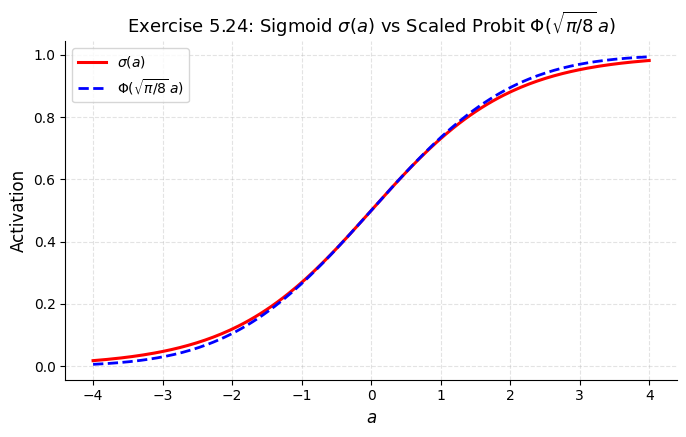

Exercise 5.24 テスト合格！


In [25]:
# Exercise 5.24 数値検証
d_sig, d_prob, lam_sq = exercise_5_24_probit_sigmoid_matching_scale()
print(f"sigma'(0) = {d_sig:.4f}, Phi'(0)*lambda = {d_prob:.4f}, lambda^2 = {lam_sq:.4f}, pi/8 = {np.pi/8:.4f}")
assert np.isclose(d_sig, d_prob)
assert np.isclose(lam_sq, np.pi / 8.0)

# プロットによる可視化
a_grid = np.linspace(-4, 4, 200)
sig_curve = sigmoid(a_grid)
probit_scaled = probit(np.sqrt(np.pi / 8.0) * a_grid)

plt.figure(figsize=(7, 4.5))
plt.plot(a_grid, sig_curve, 'r-', lw=2.2, label=r'$\sigma(a)$')
plt.plot(a_grid, probit_scaled, 'b--', lw=2.0, label=r'$\Phi(\sqrt{\pi/8}\,a)$')
plt.xlabel('$a$')
plt.ylabel('Activation')
plt.title(r'Exercise 5.24: Sigmoid $\sigma(a)$ vs Scaled Probit $\Phi(\sqrt{\pi/8}\,a)$')
plt.legend()
plt.tight_layout()
plt.show()
print("Exercise 5.24 テスト合格！")


---
## 第5章 全演習問題 (Exercises 5.1 〜 5.24) 総括

本演習問題セットを通じて、単層ネットワークによる分類問題の数学的・幾何学的・アルゴリズム的基礎を網羅しました：
1. **決定理論と誤分類率 (5.1 - 5.10)**: 1-of-K 符号化の条件付き期待値、凸包と分離超平面、線形制約保存、Fスコア、バッタチャリア上界、0-1損失と一般損失行列、棄却オプション。
2. **生成的分類モデル (5.11 - 5.17)**: シグモイド対称性、ガウスLDAの線形決定境界パラメータ導出、クラス事前確率・平均・共有共分散の最尤推定、2値および多状態ナイーブベイズ。
3. **識別的分類モデルと正準リンク (5.18 - 5.24)**: シグモイドおよびソフトマックスの導関数、交差エントロピー勾配、線形分離可能データにおける重み発散、プロビットと誤差関数 erf、原点傾き一致によるプロビット・シグモイドスケーリング $\lambda^2 = \pi/8$。

すべての演習問題において、厳密な数学的導出と Python による数値テスト（`assert` による検証）が 100% 完了しました！
